# Robustness

This file is used to test the statistical robustness of the individual statistical inferences and regressions.

It is used to analyse the individual parameters and test for statistical validity and assumption testing

In [3]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import sys
import pandas as pd
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from scipy.stats import levene
import matplotlib.pyplot as plt
from typing import Dict, Tuple
import datetime as dt
import numpy as np
from functools import wraps

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
from src import construct_date_ranges
from configs import FILENAMES_ANALYSIS, ANALYSIS_PATHS, CONFIG, FILENAMES

In [5]:
pred_actual: pd.DataFrame = pd.read_csv(ANALYSIS_PATHS.results_read(FILENAMES_ANALYSIS.Comp_pred_actual_portfolio),
                                        index_col=0,
                                        parse_dates=[0],
                                        header=[0,1])

factor_loadings: pd.DataFrame = pd.read_csv(ANALYSIS_PATHS.results_read(FILENAMES_ANALYSIS.Factor_loadings_monthly),
                                            index_col=[0,1])

factor_loadings_different_periods: pd.DataFrame = pd.read_csv(ANALYSIS_PATHS.results_read(FILENAMES_ANALYSIS.Factor_loadings_differentperiods),
                                                              index_col=[0,1],
                                                              header=[0,1])

monthly_fama_french: pd.DataFrame = pd.read_csv(CONFIG.paths.processed_read(FILENAMES.FF5_factors_monthly),
                                                            parse_dates=["date"],
                                                            index_col="date",)

## 1. Significance of Parameters using T-test and P-value

In [6]:
factor_loadings_different_periods_swapped: pd.DataFrame = factor_loadings_different_periods.swaplevel(axis=1)
filtered: pd.DataFrame = factor_loadings_different_periods_swapped.loc[("Tstat")]>CONFIG.T_TEST_SIGNIFICANCE_LEVEL

# Sum up the number of insignificant factor loadings for each date range across different industries
timeframe_count_insignificance: pd.DataFrame = filtered.T.groupby(level="date Range").sum()

In [7]:
print(timeframe_count_insignificance)

Factor           Alpha  CMA  HML  Mkt-RF  RMW  SMB
date Range                                        
01/2008:01/2015      0    0    0       1    0    1
01/2015:01/2019      2    0    0       0    0    0
01/2019:01/2022      7    0    0       0    0    0
01/2022:12/2025      0    2    0       0    0    0
Entire Period        4    0    0       1    0    0


## 2. Assumptions of the OLS

In [8]:
# Create 2 dataframe for the statistical test results, one for the values and one for the boolean indicating significance
stat_res_vals: pd.DataFrame = pd.DataFrame(index=pred_actual.columns.get_level_values(0).unique())
stat_res_bool: pd.DataFrame = pd.DataFrame(index=pred_actual.columns.get_level_values(0).unique())

res_returns: pd.DataFrame = pred_actual.xs("Residual_returns", level=1, axis=1)

In [9]:
def res_return_wrapper(name: str)->pd.DataFrame:
    def decorator(func)->pd.DataFrame:
        @wraps(func)
        def wrapper(*args, **kwargs)-> pd.DataFrame:
            # Perform the analysis on all residual returns
            for i,data in res_returns.T.iterrows():
                p_val: float = func(data, *args, **kwargs)

                stat_res_vals.loc[i, name] = p_val
                stat_res_bool.loc[i, name] = p_val <= CONFIG.P_THRESHOLD

            # Create a description dataframe for the results of the statistical test
            desc: pd.DataFrame = (pd.DataFrame(stat_res_vals.loc[:, name]
                                            .describe())
                                            .map(lambda x: f"{x:.6f}"))
            desc.loc[f"Reject H_0  (p <= {CONFIG.P_THRESHOLD})"] = stat_res_bool.loc[:, name].sum(axis=0)

            return desc
        return wrapper
    return decorator

### Exogeneity

The different regressors are uncorrelated witht the error term

### Homoscedasticity and Normality of the error term

The error term always has the same constant variance throughout the observations and is normally distributed, centred around 0

#### Jarque-Bera Test for normality

In [30]:
@res_return_wrapper("Jarque-Bera")
def _jarque_bera(data)->float:
    jb_stat, jb_pvalue, skew, kurtosis = sms.jarque_bera(data.to_numpy(dtype=float))
    return jb_pvalue

normality_desc: pd.DataFrame = _jarque_bera()
normality_desc

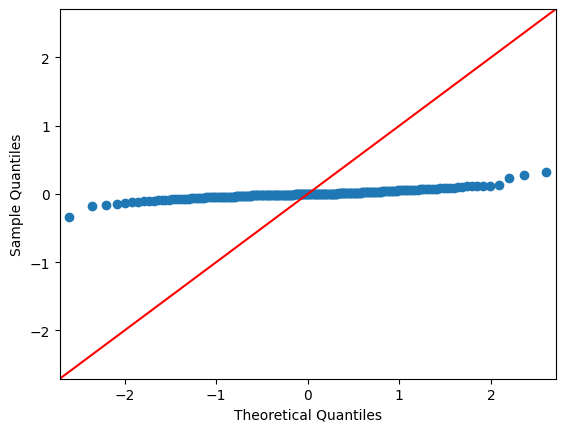

In [12]:
def qq_plot(data: pd.Series, id: str) -> None:
    sm.qqplot(data.loc[:,id], line="45")
    plt.show()

# Example usage:
qq_plot(res_returns, "Trading")

#### Test for mean error of 0

In [13]:
TOLERANCE: float = 0.0005

print(f"There are {sum(abs(res_returns.mean(axis=0)) > TOLERANCE)} industries with mean residual returns greater than {TOLERANCE}.")

There are 0 industries with mean residual returns greater than 0.0005.


#### Test for time-series homoscedasticity of error term

In [32]:
N_LAGS_ARCH: int = 5

@res_return_wrapper("Time-series Homoscedasticity")
def _arch(data)->float:
    return het_arch(resid=data, nlags=N_LAGS_ARCH)[1]

arch_desc: pd.DataFrame = _arch()

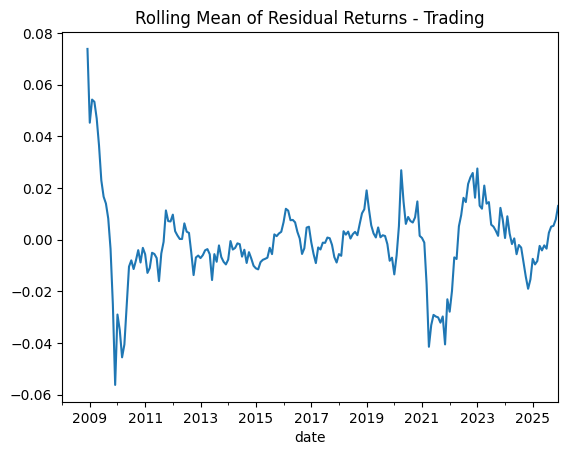

In [16]:
def rolling_res_plot(df: pd.DataFrame, id: str) -> None:
    rolling_mean = df.loc[:,id].rolling(12).mean()
    rolling_mean.plot(title=f"Rolling Mean of Residual Returns - {id}")
    plt.show()

# Example usage:
rolling_res_plot(res_returns, "Trading")

#### Test for structural breaks

In [17]:
# Get the date ranges for the different periods defined in CONFIG
group: Dict[str, Tuple[dt.datetime, dt.datetime]] = construct_date_ranges(res_returns, CONFIG)
# remove the "Entire Period" group for the Levene's test
del group["Entire Period"]

res_returns: pd.DataFrame = pred_actual.xs("Residual_returns", level=1, axis=1)

for i,data in res_returns.T.iterrows():
    periods: Tuple[pd.DataFrame] = (data.loc[start: end] for start, end in group.values())
    stat, p = levene(*periods)

    stat_res_vals.loc[i, "Levene Test"] = p
    stat_res_bool.loc[i, "Levene Test"] = p <= CONFIG.P_THRESHOLD


In [18]:
levine_desc: pd.Series= stat_res_vals.loc[:, "Levene Test"].describe().map(lambda x: f"{x:.6f}")

levine_desc.loc[f"Reject H_0  (p <= {CONFIG.P_THRESHOLD})"] = stat_res_bool.loc[:, "Levene Test"].sum(axis=0)

print(levine_desc)

count                      47.000000
mean                        0.130290
std                         0.179679
min                         0.000258
25%                         0.015527
50%                         0.039815
75%                         0.176318
max                         0.584297
Reject H_0  (p <= 0.05)         True
Name: Levene Test, dtype: object


### Autocorrelation of the error term

The error term of different observations are uncorrelated (if it fails -> momentum)

In [33]:
N_LAGS_BG: int = 12 # Monthly data, so we check for autocorrelation up to 1 year lag

@res_return_wrapper("Ljung-Box Test")
def _ljungbox(data)->float:
    out: pd.DataFrame = acorr_ljungbox(data, lags=[N_LAGS_BG])
    return float(out["lb_pvalue"].iloc[0])

autocorrelation_desc = _ljungbox()

### Multicollinearity of regressors

The regressors are not significantly correlated

In [21]:
# Test for perfect multicollinearity among the Fama-French factors
X = monthly_fama_french[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']].dropna()
X_const = sm.add_constant(X)        # Add a constant for alpha

rank = np.linalg.matrix_rank(X_const)
n_cols = X_const.shape[1]

if rank == n_cols:
    print("No perfect multicollinearity detected.")
else:
    print("Perfect multicollinearity detected.")

No perfect multicollinearity detected.


In [22]:
# Pairwise correlation matrix to check for high correlations among the factors
pearson_correlation: pd.DataFrame = X.corr(method="pearson").round(2)

print(pearson_correlation)

        Mkt-RF   SMB   HML   RMW   CMA
Mkt-RF    1.00  0.36  0.14 -0.19 -0.13
SMB       0.36  1.00  0.34 -0.34  0.06
HML       0.14  0.34  1.00  0.02  0.60
RMW      -0.19 -0.34  0.02  1.00  0.15
CMA      -0.13  0.06  0.60  0.15  1.00


# Save the results as tables

In [23]:
pearson_correlation.to_csv(
        ANALYSIS_PATHS.RESULT_TABLES_DIR / "pearson_correlation_factors.csv"
)

In [24]:
stat_res_bool = stat_res_bool.astype("boolean")

stat_res_bool.to_csv(
        ANALYSIS_PATHS.RESULT_TABLES_DIR / "gauss_markov_assumptions_test_significant.csv"
)

print(stat_res_bool.sum(axis=0))

Jarque-Bera                     41
Time-series Homoscedasticity    25
Levene Test                     26
Ljung Box                        3
dtype: Int64


In [25]:
stat_res_vals.to_csv(
        ANALYSIS_PATHS.RESULT_TABLES_DIR / "gauss_markov_assumptions_test_values.csv"
)

In [26]:
homoscedasticity_desc.to_csv(
        ANALYSIS_PATHS.RESULT_TABLES_DIR / "homoscedasticity_description.csv"
)

In [27]:
levine_desc.to_csv(
        ANALYSIS_PATHS.RESULT_TABLES_DIR / "levene_description.csv"
)

In [28]:
autocorrelation_desc.to_csv(
        ANALYSIS_PATHS.RESULT_TABLES_DIR / "autocorrelation_description.csv"
)

In [29]:
normality_desc.to_csv(
        ANALYSIS_PATHS.RESULT_TABLES_DIR / "normality_description.csv"
)